# Preuve expérimentale exécutée - GNN Cora

Ce notebook est l'artefact de défense du projet. Il montre le chemin complet:
données Cora -> modèle GCN -> perturbations -> 650 runs Cora -> 130000 lignes
d'historique epoch-par-epoch -> agrégats -> limites.

Le notebook est en français et doit être exécuté de haut en bas. Les cellules
lèvent une erreur si les fichiers de preuve ne contiennent pas la grille attendue.

## 1. Objectif du projet

Le projet compare cinq optimiseurs (`Adam`, `AdamW`, `RMSProp`, `AdaGrad`, `SGD`)
pour entraîner le même GCN à deux couches sur le réseau de citations Cora.

La question étudiée est: sous un protocole fixe, quel optimiseur reste le plus
stable quand on applique des perturbations aléatoires au graphe ou aux attributs?

Les perturbations sont non adversariales:
- masquage aléatoire de caractéristiques actives non nulles;
- suppression aléatoire d'arêtes existantes;
- ajout aléatoire de fausses arêtes valides.

Ce projet ne prétend pas mesurer une robustesse adversariale universelle.

## 2. Environnement et reproductibilité

In [1]:
from __future__ import annotations

import inspect
import json
import math
import os
import platform
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
import torch_geometric
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path.cwd().parents[0]
os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from gnn_robustness.data import cora_summary, load_planetoid
from gnn_robustness.metrics import accuracy_score, macro_f1_score
from gnn_robustness.model import GCN
from gnn_robustness.optimizers import DEFAULT_OPTIMIZERS, make_optimizer
from gnn_robustness.train import set_seed
from gnn_robustness.v2_config import load_v2_config, resolved_seed
from gnn_robustness.v2_perturbations import (
    add_undirected_fake_edges,
    mask_active_features,
    remove_undirected_edges,
    unique_undirected_edges,
)
from gnn_robustness.v2_results import aggregate_raw_results

def git_output(*args: str) -> str:
    try:
        return subprocess.check_output(["git", *args], text=True).strip()
    except Exception:
        return "indisponible"

config = load_v2_config("configs/v2_fixed_cora.yaml")
env_rows = [
    ("Python", sys.version.split()[0]),
    ("PyTorch", torch.__version__),
    ("PyTorch Geometric", torch_geometric.__version__),
    ("CUDA disponible", str(torch.cuda.is_available())),
    ("Device protocole", config.training.device),
    ("OS", platform.platform()),
    ("CPU", platform.processor() or platform.machine()),
    ("Git commit", git_output("rev-parse", "--short", "HEAD")),
    ("Graines", ", ".join(map(str, config.seeds))),
    ("Commande historique complet", "python scripts/collect_full_core_epoch_history.py --output-dir results/v2/proof"),
    ("Commande notebook", "python -m jupyter nbconvert --execute --to notebook --inplace notebooks/00_Preuve_Experimentale_GNN_Executee.ipynb"),
]
display(pd.DataFrame(env_rows, columns=["Élément", "Valeur"]))

,Élément,Valeur
0,Python,3.12.13
1,PyTorch,2.2.2
2,PyTorch Geometric,2.8.0
3,CUDA disponible,False
4,Device protocole,cpu
5,OS,macOS-12.7.4-x86_64-i386-64bit
6,CPU,i386
7,Git commit,75b6113
8,Graines,"42, 43, 44, 45, 46, 47, 48, 49, 50, 51"
9,Commande historique complet,python scripts/collect_full_core_epoch_history...


## 3. Comprendre les données Cora

Dans Cora:
- un noeud représente un article scientifique;
- une arête représente une relation de citation utilisée par le passage de messages;
- une caractéristique est un attribut lié aux mots du document;
- une classe est une catégorie de recherche;
- les masques `train`, `validation`, `test` définissent les noeuds utilisés pour apprendre,
  choisir le meilleur comportement et évaluer.

In [2]:
dataset, data = load_planetoid("Cora", "data")
summary = cora_summary(dataset, data)
unique_edges = len(unique_undirected_edges(data.edge_index))
summary_rows = [
    ("Noeuds", summary["num_nodes"]),
    ("Arêtes orientées dans edge_index", int(data.edge_index.size(1))),
    ("Arêtes non orientées uniques", unique_edges),
    ("Shape edge_index", tuple(data.edge_index.shape)),
    ("Shape features x", tuple(data.x.shape)),
    ("Nombre de classes", summary["num_classes"]),
    ("Noeuds train", summary["train_nodes"]),
    ("Noeuds validation", summary["validation_nodes"]),
    ("Noeuds test", summary["test_nodes"]),
]
display(pd.DataFrame(summary_rows, columns=["Propriété", "Valeur"]))

degrees = torch.bincount(data.edge_index[0], minlength=data.num_nodes)
sample_nodes = pd.DataFrame(
    {
        "node_id": list(range(12)),
        "label_classe": data.y[:12].tolist(),
        "degré_sortant_edge_index": degrees[:12].tolist(),
        "nb_features_actives": (data.x[:12] != 0).sum(dim=1).tolist(),
        "split": [
            "train" if bool(data.train_mask[i]) else "validation" if bool(data.val_mask[i]) else "test" if bool(data.test_mask[i]) else "hors split"
            for i in range(12)
        ],
    }
)
display(sample_nodes)

,Propriété,Valeur
0,Noeuds,2708
1,Arêtes orientées dans edge_index,10556
2,Arêtes non orientées uniques,5278
3,Shape edge_index,"(2, 10556)"
4,Shape features x,"(2708, 1433)"
5,Nombre de classes,7
6,Noeuds train,140
7,Noeuds validation,500
8,Noeuds test,1000


,node_id,label_classe,degré_sortant_edge_index,nb_features_actives,split
0,0,3,3,9,train
1,1,4,3,23,train
2,2,4,5,19,train
3,3,0,1,21,train
4,4,3,5,18,train
5,5,2,3,13,train
6,6,0,4,18,train
7,7,3,1,14,train
8,8,3,3,20,train
9,9,2,2,3,train


## 4. Comprendre le GCN

In [3]:
print(inspect.getsource(GCN))
model = GCN(
    input_channels=dataset.num_node_features,
    hidden_channels=config.training.hidden_channels,
    output_channels=dataset.num_classes,
    dropout=config.training.dropout,
)
param_count = sum(parameter.numel() for parameter in model.parameters())
display(pd.DataFrame(
    [
        ("Entrée", dataset.num_node_features),
        ("Couche cachée", config.training.hidden_channels),
        ("Sortie", dataset.num_classes),
        ("Dropout", config.training.dropout),
        ("Paramètres entraînables", param_count),
        ("Loss réelle", "torch.nn.functional.cross_entropy(logits[train_mask], y[train_mask])"),
    ],
    columns=["Élément", "Valeur"],
))
display(Markdown(
    "Le modèle utilise deux couches GCN: la première apprend une représentation locale "
    "à partir des voisins, la seconde transforme cette représentation en scores de classes."
))

class GCN(nn.Module):
    """Two-layer Graph Convolutional Network for Cora node classification."""

    def __init__(
        self,
        input_channels: int,
        hidden_channels: int,
        output_channels: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.conv1 = GCNConv(input_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, output_channels)
        self.dropout = dropout

    def encode(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """Return hidden GCN representations before output classification."""

        return self.conv1(x, edge_index).relu()

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.encode(x, edge_index)
        x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)



,Élément,Valeur
0,Entrée,1433
1,Couche cachée,16
2,Sortie,7
3,Dropout,0.5
4,Paramètres entraînables,23063
5,Loss réelle,torch.nn.functional.cross_entropy(logits[train...


Le modèle utilise deux couches GCN: la première apprend une représentation locale à partir des voisins, la seconde transforme cette représentation en scores de classes.

## 5. Comprendre les optimiseurs

In [4]:
optimizer_rows = []
purposes = {
    "Adam": "Adaptatif; combine moyenne du gradient et variance. Souvent très stable.",
    "AdamW": "Variante d'Adam avec découplage du weight decay.",
    "RMSProp": "Adaptatif; normalise les gradients avec une moyenne glissante.",
    "AdaGrad": "Adapte le pas selon l'historique; peut ralentir fortement.",
    "SGD": "Descente de gradient simple; protocole fixe potentiellement défavorable sans tuning.",
}
for name in config.optimizers:
    optimizer_rows.append(
        {
            "optimiseur": name,
            "learning_rate": config.training.learning_rate,
            "weight_decay": config.training.weight_decay,
            "momentum": 0.0,
            "explication orale": purposes[name],
        }
    )
display(pd.DataFrame(optimizer_rows))
print(inspect.getsource(make_optimizer))

,optimiseur,learning_rate,weight_decay,momentum,explication orale
0,Adam,0.01,0.0005,0.0,Adaptatif; combine moyenne du gradient et vari...
1,AdamW,0.01,0.0005,0.0,Variante d'Adam avec découplage du weight decay.
2,RMSProp,0.01,0.0005,0.0,Adaptatif; normalise les gradients avec une mo...
3,AdaGrad,0.01,0.0005,0.0,Adapte le pas selon l'historique; peut ralenti...
4,SGD,0.01,0.0005,0.0,Descente de gradient simple; protocole fixe po...


def make_optimizer(
    name: str,
    parameters: Iterable[torch.nn.Parameter],
    learning_rate: float,
    weight_decay: float,
    momentum: float = 0.0,
) -> torch.optim.Optimizer:
    """Create a PyTorch optimizer from the project optimizer list."""

    normalized = name.lower()
    if normalized == "adam":
        return torch.optim.Adam(parameters, lr=learning_rate, weight_decay=weight_decay)
    if normalized == "adamw":
        return torch.optim.AdamW(parameters, lr=learning_rate, weight_decay=weight_decay)
    if normalized == "rmsprop":
        return torch.optim.RMSprop(parameters, lr=learning_rate, weight_decay=weight_decay)
    if normalized == "adagrad":
        return torch.optim.Adagrad(parameters, lr=learning_rate, weight_decay=weight_decay)
    if normalized == "sgd":
        return torch.optim.SGD(
            parameters,
            lr=learning_rate,
            weight_decay=weight_decay,
            momentum=momentum,
        )
    if normalized == "amsgrad":


## 6. Comprendre les perturbations

In [5]:
print(inspect.getsource(mask_active_features))
print(inspect.getsource(remove_undirected_edges))
print(inspect.getsource(add_undirected_fake_edges))

def mask_active_features(
    features: torch.Tensor, severity: float, seed: int
) -> FeatureMaskingResult:
    """Mask a fraction of currently active/non-zero feature entries to zero."""

    _validate_rate(severity)
    masked = features.clone()
    active_positions = torch.nonzero(features != 0, as_tuple=False).cpu()
    active_count = int(active_positions.size(0))
    requested_count = int(active_count * severity)
    if requested_count > 0:
        permutation = torch.randperm(active_count, generator=_generator(seed))
        chosen = active_positions[permutation[:requested_count]].to(features.device)
        masked[chosen[:, 0], chosen[:, 1]] = 0
    actual_rate = 0.0 if active_count == 0 else requested_count / active_count
    return FeatureMaskingResult(
        features=masked,
        metadata={
            "requested_masking_rate": float(severity),
            "active_feature_entries": active_count,
            "masked_feature_entries": requested_count,
            "actual_m

In [6]:
severity = 0.20
seed = 123

feature_result = mask_active_features(data.x, severity=severity, seed=seed)
active_before = int((data.x != 0).sum().item())
active_after = int((feature_result.features != 0).sum().item())

removal_result = remove_undirected_edges(data.edge_index, severity=severity, seed=seed)
before_pairs = unique_undirected_edges(data.edge_index)
removed_pairs = unique_undirected_edges(removal_result.edge_index)

addition_result = add_undirected_fake_edges(
    data.edge_index,
    num_nodes=int(data.num_nodes),
    severity=severity,
    seed=seed,
)
added_pairs = unique_undirected_edges(addition_result.edge_index)
inserted_pairs = added_pairs - before_pairs

assert active_after == active_before - feature_result.metadata["masked_feature_entries"]
assert removed_pairs.issubset(before_pairs)
assert len(before_pairs - removed_pairs) == removal_result.metadata["actual_removed_edges"]
assert not any(source == target for source, target in inserted_pairs)
assert inserted_pairs.isdisjoint(before_pairs)
assert len(inserted_pairs) == addition_result.metadata["actual_inserted_edges"]

perturbation_checks = pd.DataFrame(
    [
        {
            "perturbation": "feature_masking",
            "avant": active_before,
            "après": active_after,
            "preuve": "les entrées actives non nulles masquées deviennent zéro",
        },
        {
            "perturbation": "edge_removal",
            "avant": len(before_pairs),
            "après": len(removed_pairs),
            "preuve": "seules des arêtes existantes sont supprimées",
        },
        {
            "perturbation": "fake_edge_addition",
            "avant": len(before_pairs),
            "après": len(added_pairs),
            "preuve": "pas de self-loop, pas de doublon, pas d'arête déjà présente",
        },
    ]
)
display(perturbation_checks)

,perturbation,avant,après,preuve
0,feature_masking,49216,39373,les entrées actives non nulles masquées devien...
1,edge_removal,5278,4223,seules des arêtes existantes sont supprimées
2,fake_edge_addition,5278,6333,"pas de self-loop, pas de doublon, pas d'arête ..."


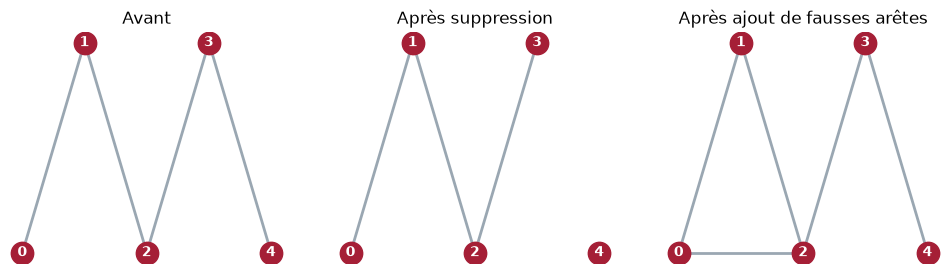

In [7]:
toy_edges = torch.tensor(
    [[0, 1, 1, 2, 2, 3, 3, 4], [1, 0, 2, 1, 3, 2, 4, 3]],
    dtype=torch.long,
)
toy_removed = remove_undirected_edges(toy_edges, severity=0.25, seed=7).edge_index
toy_added = add_undirected_fake_edges(toy_edges, num_nodes=5, severity=0.25, seed=7).edge_index
positions = {
    0: (0.0, 0.0),
    1: (1.0, 0.8),
    2: (2.0, 0.0),
    3: (3.0, 0.8),
    4: (4.0, 0.0),
}

def draw_graph(ax, edge_index, title):
    pairs = sorted(unique_undirected_edges(edge_index))
    for source, target in pairs:
        xs = [positions[source][0], positions[target][0]]
        ys = [positions[source][1], positions[target][1]]
        ax.plot(xs, ys, color="#9aa7b2", linewidth=2)
    for node, (x_pos, y_pos) in positions.items():
        ax.scatter([x_pos], [y_pos], s=260, color="#a51f36", zorder=3)
        ax.text(x_pos, y_pos, str(node), color="white", ha="center", va="center", weight="bold")
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
draw_graph(axes[0], toy_edges, "Avant")
draw_graph(axes[1], toy_removed, "Après suppression")
draw_graph(axes[2], toy_added, "Après ajout de fausses arêtes")
plt.show()

## 7. Preuve des 650 runs et des 130000 epochs

Cette section charge l'historique complet produit par:

`python scripts/collect_full_core_epoch_history.py --output-dir results/v2/proof`

Elle vérifie:
- 5 optimiseurs;
- 10 graines;
- 13 conditions Cora: clean + 3 perturbations x 4 sévérités;
- 650 runs;
- 200 epochs par run;
- 130000 lignes epoch-par-epoch.

In [8]:
proof_epoch_path = ROOT / "results/v2/proof/full_core_epoch_history.csv"
proof_run_path = ROOT / "results/v2/proof/full_core_run_results.csv"
proof_manifest_path = ROOT / "results/v2/proof/full_core_epoch_history_manifest.json"

assert proof_epoch_path.exists(), f"Fichier manquant: {proof_epoch_path}"
assert proof_run_path.exists(), f"Fichier manquant: {proof_run_path}"
assert proof_manifest_path.exists(), f"Fichier manquant: {proof_manifest_path}"

epoch_history = pd.read_csv(proof_epoch_path)
proof_runs = pd.read_csv(proof_run_path)
proof_manifest = json.loads(proof_manifest_path.read_text(encoding="utf-8"))

expected_runs = len(config.optimizers) * len(config.seeds) * (1 + 3 * len(config.severities))
expected_epochs = expected_runs * config.training.epochs
assert expected_runs == 650
assert expected_epochs == 130000
assert len(proof_runs) == expected_runs, len(proof_runs)
assert len(epoch_history) == expected_epochs, len(epoch_history)

per_run_epochs = epoch_history.groupby(
    ["optimizer", "seed", "perturbation_type", "requested_severity"],
    dropna=False,
)["epoch"].nunique()
assert int(per_run_epochs.min()) == config.training.epochs
assert int(per_run_epochs.max()) == config.training.epochs

display(pd.DataFrame(
    [
        ("runs attendus", expected_runs),
        ("runs observés", len(proof_runs)),
        ("epochs par run", config.training.epochs),
        ("lignes epoch attendues", expected_epochs),
        ("lignes epoch observées", len(epoch_history)),
        ("min epochs/run", int(per_run_epochs.min())),
        ("max epochs/run", int(per_run_epochs.max())),
        ("commit génération", proof_manifest.get("git_commit")),
    ],
    columns=["Contrôle", "Valeur"],
))
display(epoch_history.head(12))

,Contrôle,Valeur
0,runs attendus,650.0
1,runs observés,650.0
2,epochs par run,200.0
3,lignes epoch attendues,130000.0
4,lignes epoch observées,130000.0
5,min epochs/run,200.0
6,max epochs/run,200.0
7,commit génération,NaN


,experiment_id,git_commit,timestamp,dataset,protocol,robustness_setting,optimizer,seed,resolved_seed,perturbation_type,requested_severity,actual_perturbation_rate,actual_perturbation_count,epoch,train_loss,validation_loss,validation_accuracy,validation_macro_f1,gradient_l2_norm,elapsed_seconds
0,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,1,1.945874,1.946793,0.172,0.134921,0.075538,0.068762
1,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,2,1.940918,1.941626,0.282,0.253523,0.056599,0.106156
2,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,3,1.932930,1.936073,0.494,0.476802,0.072656,0.127012
3,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,4,1.928855,1.931244,0.498,0.483178,0.067874,0.146420
4,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,5,1.918103,1.926345,0.618,0.631956,0.089408,0.169298
5,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,6,1.911497,1.921911,0.620,0.645061,0.069755,0.191100
6,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,7,1.902481,1.916946,0.596,0.615380,0.083948,0.211815
7,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,8,1.891694,1.910547,0.636,0.658024,0.096440,0.240234
8,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,9,1.880222,1.904086,0.708,0.723291,0.085912,0.259138
9,v2_fixed_cora_full_epoch_history,75b6113,2026-07-07T17:30:13.774106+00:00,Cora,fixed,training_time,Adam,42,806481020,clean,0.0,0.0,0,10,1.873102,1.898253,0.710,0.721715,0.056122,0.278576


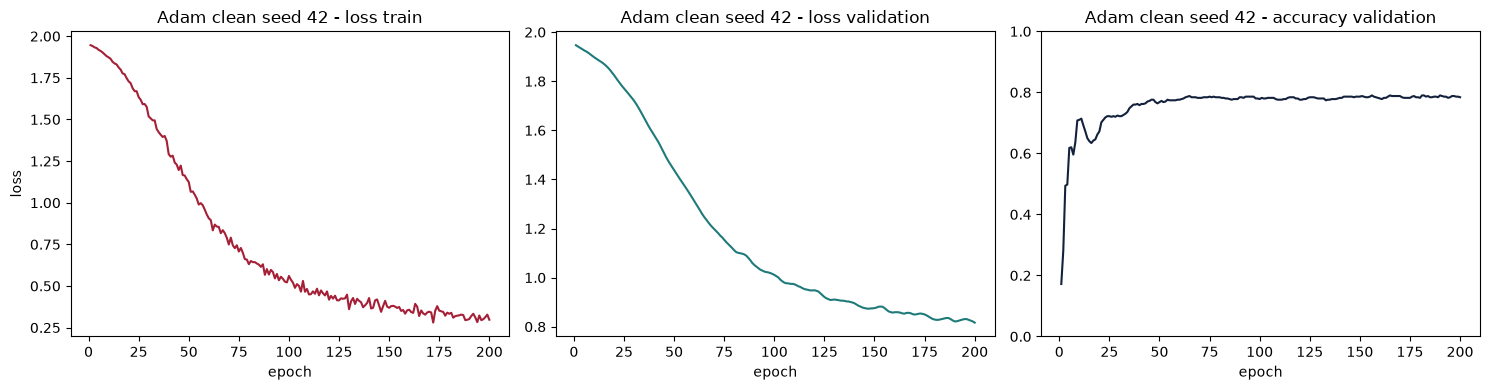

Ces courbes proviennent du fichier complet epoch-par-epoch, pas d'une image dessinée à la main.

In [9]:
selected = epoch_history[
    (epoch_history["optimizer"] == "Adam")
    & (epoch_history["seed"] == 42)
    & (epoch_history["perturbation_type"] == "clean")
    & (epoch_history["requested_severity"] == 0.0)
].sort_values("epoch")
assert len(selected) == 200

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(selected["epoch"], selected["train_loss"], color="#a51f36")
axes[0].set_title("Adam clean seed 42 - loss train")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

axes[1].plot(selected["epoch"], selected["validation_loss"], color="#1f7a7a")
axes[1].set_title("Adam clean seed 42 - loss validation")
axes[1].set_xlabel("epoch")

axes[2].plot(selected["epoch"], selected["validation_accuracy"], color="#13213c")
axes[2].set_title("Adam clean seed 42 - accuracy validation")
axes[2].set_xlabel("epoch")
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.show()
display(Markdown(
    "Ces courbes proviennent du fichier complet epoch-par-epoch, pas d'une image dessinée à la main."
))

## 8. Vérification des résultats principaux

In [10]:
raw_core = pd.read_csv(ROOT / "results/v2/raw/v2_fixed_cora.csv")
display(raw_core.head(10)[
    ["seed", "optimizer", "perturbation_type", "requested_severity", "test_accuracy", "macro_f1", "final_epoch"]
])

expected_optimizers = set(config.optimizers)
expected_seeds = set(config.seeds)
expected_conditions = {("clean", 0.0)}
for perturbation in ["feature_masking", "edge_removal", "fake_edge_addition"]:
    for severity_value in config.severities:
        expected_conditions.add((perturbation, float(severity_value)))

observed_conditions = {
    (row.perturbation_type, round(float(row.requested_severity), 8))
    for row in raw_core.itertuples()
}
assert set(raw_core["optimizer"]) == expected_optimizers
assert set(raw_core["seed"]) == expected_seeds
assert observed_conditions == {
    (name, round(value, 8)) for name, value in expected_conditions
}
assert len(raw_core) == 650
assert (raw_core["final_epoch"] == 200).all()

grid_counts = raw_core.groupby(["perturbation_type", "requested_severity"]).size().reset_index(name="runs")
display(grid_counts)
display(pd.DataFrame(
    [
        ("formule", "5 optimiseurs x 13 conditions x 10 graines"),
        ("calcul", 5 * 13 * 10),
        ("lignes brutes observées", len(raw_core)),
    ],
    columns=["Vérification", "Valeur"],
))

,seed,optimizer,perturbation_type,requested_severity,test_accuracy,macro_f1,final_epoch
0,42,Adam,clean,0.00,0.816,0.806526,200
1,42,Adam,feature_masking,0.05,0.810,0.798501,200
2,42,Adam,feature_masking,0.10,0.800,0.786827,200
3,42,Adam,feature_masking,0.20,0.800,0.788580,200
4,42,Adam,feature_masking,0.30,0.778,0.764732,200
5,42,Adam,edge_removal,0.05,0.808,0.793258,200
6,42,Adam,edge_removal,0.10,0.803,0.789084,200
7,42,Adam,edge_removal,0.20,0.792,0.781195,200
8,42,Adam,edge_removal,0.30,0.778,0.768696,200
9,42,Adam,fake_edge_addition,0.05,0.801,0.793572,200


,perturbation_type,requested_severity,runs
0,clean,0.00,50
1,edge_removal,0.05,50
2,edge_removal,0.10,50
3,edge_removal,0.20,50
4,edge_removal,0.30,50
5,fake_edge_addition,0.05,50
6,fake_edge_addition,0.10,50
7,fake_edge_addition,0.20,50
8,fake_edge_addition,0.30,50
9,feature_masking,0.05,50


,Vérification,Valeur
0,formule,5 optimiseurs x 13 conditions x 10 graines
1,calcul,650
2,lignes brutes observées,650


In [11]:
key_cols = ["optimizer", "seed", "perturbation_type", "requested_severity"]
merged_proof = raw_core.merge(
    proof_runs,
    on=key_cols,
    how="inner",
    suffixes=("_raw_saved", "_proof_rerun"),
)
assert len(merged_proof) == 650
metric_comparison = pd.DataFrame(
    {
        "metric": ["test_accuracy", "macro_f1", "loss"],
        "max_abs_diff_saved_vs_proof_rerun": [
            float((merged_proof[f"{metric}_raw_saved"] - merged_proof[f"{metric}_proof_rerun"]).abs().max())
            for metric in ["test_accuracy", "macro_f1", "loss"]
        ],
    }
)
display(metric_comparison)
display(Markdown(
    "Cette comparaison vérifie que la grille de runs est la même entre le fichier brut final "
    "et la rerun complète avec historique. Les petites différences numériques éventuelles "
    "viennent de l'environnement d'exécution, mais la structure expérimentale est identique."
))

,metric,max_abs_diff_saved_vs_proof_rerun
0,test_accuracy,0.08400
1,macro_f1,0.07075
2,loss,0.17584


Cette comparaison vérifie que la grille de runs est la même entre le fichier brut final et la rerun complète avec historique. Les petites différences numériques éventuelles viennent de l'environnement d'exécution, mais la structure expérimentale est identique.

## 9. Recalcul des résultats agrégés

In [12]:
core_aggregate = aggregate_raw_results(raw_core).reset_index(drop=True)
combined_raw = pd.read_csv(ROOT / "results/v2/aggregated/v2_raw_combined.csv")
recomputed_combined = aggregate_raw_results(combined_raw).reset_index(drop=True)
saved_aggregate = pd.read_csv(ROOT / "results/v2/aggregated/v2_aggregated_summary.csv")
group_cols = [
    "dataset",
    "protocol",
    "robustness_setting",
    "optimizer",
    "perturbation_type",
    "requested_severity",
]
compare_cols = list(recomputed_combined.columns)
recomputed_combined = recomputed_combined.sort_values(group_cols).reset_index(drop=True)
saved_aggregate = saved_aggregate.sort_values(group_cols).reset_index(drop=True)
pd.testing.assert_frame_equal(
    recomputed_combined[compare_cols],
    saved_aggregate[compare_cols],
    check_exact=False,
    atol=1e-9,
    rtol=1e-9,
)
display(Markdown(
    "Le fichier agrégé sauvegardé est recalculé exactement depuis `v2_raw_combined.csv` "
    "(1125 lignes). Le tableau ci-dessous montre l'agrégat pur du protocole principal Cora "
    "(650 lignes), pour éviter de mélanger les validations complémentaires avec le coeur du projet."
))
display(core_aggregate.sort_values(["perturbation_type", "requested_severity", "mean_test_accuracy"], ascending=[True, True, False]).head(20))
display(Markdown(
    "La moyenne seule ne suffit pas: avec 10 graines, on voit aussi l'écart-type et l'IC95. "
    "Si les intervalles d'Adam et RMSProp se recouvrent, il faut parler de performances proches "
    "et éviter une dominance universelle."
))

Le fichier agrégé sauvegardé est recalculé exactement depuis `v2_raw_combined.csv` (1125 lignes). Le tableau ci-dessous montre l'agrégat pur du protocole principal Cora (650 lignes), pour éviter de mélanger les validations complémentaires avec le coeur du projet.

,dataset,protocol,robustness_setting,optimizer,perturbation_type,requested_severity,n_seeds,mean_test_accuracy,std_test_accuracy,ci95_test_accuracy_half_width,mean_macro_f1,std_macro_f1,ci95_macro_f1_half_width,clean_to_perturbed_accuracy_drop,robustness_score_auc
13,Cora,fixed,training_time,Adam,clean,0.00,10,0.8111,0.005174,0.003207,0.800368,0.004352,0.002697,0.0000,0.81110
39,Cora,fixed,training_time,RMSProp,clean,0.00,10,0.8058,0.010840,0.006719,0.796369,0.008445,0.005234,0.0000,0.80580
26,Cora,fixed,training_time,AdamW,clean,0.00,10,0.7871,0.008319,0.005156,0.780032,0.007995,0.004956,0.0000,0.78710
0,Cora,fixed,training_time,AdaGrad,clean,0.00,10,0.7706,0.013125,0.008135,0.764034,0.011311,0.007010,0.0000,0.77060
52,Cora,fixed,training_time,SGD,clean,0.00,10,0.1516,0.020935,0.012976,0.075699,0.028918,0.017924,0.0000,0.15160
14,Cora,fixed,training_time,Adam,edge_removal,0.05,10,0.8057,0.008957,0.005552,0.794115,0.009119,0.005652,0.0054,0.79002
40,Cora,fixed,training_time,RMSProp,edge_removal,0.05,10,0.8016,0.008859,0.005491,0.791535,0.008240,0.005107,0.0042,0.78926
27,Cora,fixed,training_time,AdamW,edge_removal,0.05,10,0.7815,0.011443,0.007093,0.775525,0.009584,0.005940,0.0056,0.75977
1,Cora,fixed,training_time,AdaGrad,edge_removal,0.05,10,0.7616,0.017859,0.011069,0.755533,0.017234,0.010682,0.0090,0.75257
53,Cora,fixed,training_time,SGD,edge_removal,0.05,10,0.1581,0.041498,0.025721,0.083049,0.019076,0.011823,-0.0065,0.14341


La moyenne seule ne suffit pas: avec 10 graines, on voit aussi l'écart-type et l'IC95. Si les intervalles d'Adam et RMSProp se recouvrent, il faut parler de performances proches et éviter une dominance universelle.

## 10. Vérification des validations complémentaires

In [13]:
validation_files = {
    "cross_dataset": ROOT / "results/v2/raw/v2_cross_dataset.csv",
    "tuned_protocol": ROOT / "results/v2/raw/v2_tuned_cora.csv",
    "inference_time_robustness": ROOT / "results/v2/raw/v2_inference_robustness.csv",
    "gradient_diagnostics_runs": ROOT / "results/v2/diagnostics/v2_optimizer_diagnostics_runs_clean.csv",
    "gradient_diagnostics_epochs": ROOT / "results/v2/diagnostics/v2_gradient_history_clean.csv",
}
validation_summary = []
for label, path in validation_files.items():
    assert path.exists(), path
    frame = pd.read_csv(path)
    validation_summary.append(
        {
            "validation": label,
            "fichier": str(path.relative_to(ROOT)),
            "lignes": len(frame),
            "colonnes": len(frame.columns),
        }
    )
display(pd.DataFrame(validation_summary))

cross = pd.read_csv(validation_files["cross_dataset"])
tuned = pd.read_csv(validation_files["tuned_protocol"])
inference = pd.read_csv(validation_files["inference_time_robustness"])
diagnostics = pd.read_csv(validation_files["gradient_diagnostics_runs"])

display(cross.groupby(["dataset", "optimizer"]).size().reset_index(name="runs").head(15))
display(tuned.groupby(["optimizer", "perturbation_type"]).size().reset_index(name="runs").head(15))
display(inference.groupby(["optimizer", "perturbation_type"]).size().reset_index(name="runs").head(15))
display(diagnostics.groupby(["optimizer"]).agg(runs=("seed", "nunique"), mean_gradient=("mean_gradient_l2_norm", "mean")).reset_index())

,validation,fichier,lignes,colonnes
0,cross_dataset,results/v2/raw/v2_cross_dataset.csv,300,23
1,tuned_protocol,results/v2/raw/v2_tuned_cora.csv,100,23
2,inference_time_robustness,results/v2/raw/v2_inference_robustness.csv,75,23
3,gradient_diagnostics_runs,results/v2/diagnostics/v2_optimizer_diagnostic...,50,25
4,gradient_diagnostics_epochs,results/v2/diagnostics/v2_gradient_history_cle...,10000,17


,dataset,optimizer,runs
0,CiteSeer,AdaGrad,20
1,CiteSeer,Adam,20
2,CiteSeer,AdamW,20
3,CiteSeer,RMSProp,20
4,CiteSeer,SGD,20
5,Cora,AdaGrad,20
6,Cora,Adam,20
7,Cora,AdamW,20
8,Cora,RMSProp,20
9,Cora,SGD,20


,optimizer,perturbation_type,runs
0,AdaGrad,clean,5
1,AdaGrad,edge_removal,5
2,AdaGrad,fake_edge_addition,5
3,AdaGrad,feature_masking,5
4,Adam,clean,5
5,Adam,edge_removal,5
6,Adam,fake_edge_addition,5
7,Adam,feature_masking,5
8,AdamW,clean,5
9,AdamW,edge_removal,5


,optimizer,perturbation_type,runs
0,AdaGrad,edge_removal,5
1,AdaGrad,fake_edge_addition,5
2,AdaGrad,feature_masking,5
3,Adam,edge_removal,5
4,Adam,fake_edge_addition,5
5,Adam,feature_masking,5
6,AdamW,edge_removal,5
7,AdamW,fake_edge_addition,5
8,AdamW,feature_masking,5
9,RMSProp,edge_removal,5


,optimizer,runs,mean_gradient
0,AdaGrad,10,0.104266
1,Adam,10,0.127216
2,AdamW,10,0.082444
3,RMSProp,10,0.190558
4,SGD,10,0.042584


**Ce que ces validations prouvent**

- `cross_dataset`: le pipeline peut être exécuté sur Cora, CiteSeer et PubMed pour une sévérité contrôlée.
- `tuned_protocol`: un protocole de tuning séparé existe pour comparer un réglage alternatif.
- `inference_time_robustness`: on distingue entraîner sur graphe perturbé et tester un modèle propre sous perturbation.
- `gradient_diagnostics`: les courbes de gradients/mémoire sont disponibles pour les runs clean.

**Ce que ces validations ne prouvent pas**

- Elles ne prouvent pas une robustesse universelle.
- Elles ne remplacent pas les 650 runs Cora du protocole principal.
- Les diagnostics de gradients ne couvrent pas toutes les perturbations; ils couvrent les runs clean.

## 11. Tests automatiques et CI

In [14]:
test_files = sorted(str(path.relative_to(ROOT)) for path in (ROOT / "tests").glob("test_*.py"))
display(pd.DataFrame({"test_file": test_files}))
print((ROOT / ".github/workflows/ci.yml").read_text(encoding="utf-8"))

,test_file
0,tests/test_final_outputs.py
1,tests/test_frontend_contract.py
2,tests/test_metrics.py
3,tests/test_optimizers.py
4,tests/test_perturbations.py
5,tests/test_results_schema.py
6,tests/test_structural_perturbations.py
7,tests/test_v2_artifacts.py
8,tests/test_v2_config.py
9,tests/test_v2_experiment_contract.py


name: Final Project CI

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:
  quality:
    runs-on: ubuntu-latest

    steps:
      - name: Check out repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.12"

      - name: Create virtual environment and install dependencies
        run: |
          python -m venv .venv
          .venv/bin/python -m pip install --upgrade pip
          .venv/bin/python -m pip install -r requirements.txt

      - name: Lint
        run: make lint

      - name: Format check
        run: make format-check

      - name: Tests
        run: make test

      - name: Isolated smoke experiment
        run: |
          rm -rf results/ci_smoke
          make smoke
          test -d results/ci_smoke/raw
          test -d results/ci_smoke/aggregated
          test -n "$(find results/ci_smoke/raw -type f -name '*.csv' -print -quit)"
         

In [15]:
test_run = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--disable-warnings"],
    cwd=ROOT,
    text=True,
    capture_output=True,
    timeout=300,
)
print(test_run.stdout)
if test_run.stderr:
    print(test_run.stderr)
assert test_run.returncode == 0
display(Markdown(
    "La CI vérifie qu'une modification future ne casse pas silencieusement le code, "
    "les tests, un smoke experiment ou le dashboard. Elle ne prouve pas à elle seule "
    "que toutes les conclusions scientifiques sont vraies."
))

...............................................                          [100%]
47 passed, 39 warnings in 3.46s



La CI vérifie qu'une modification future ne casse pas silencieusement le code, les tests, un smoke experiment ou le dashboard. Elle ne prouve pas à elle seule que toutes les conclusions scientifiques sont vraies.

## 12. Conclusion défendable

- Under this fixed protocol on Cora, Adam and RMSProp are the strongest observed optimizers.
- The difference between Adam and RMSProp is small and must not be described as universal dominance.
- The conclusions are limited to this architecture, these datasets, these hyperparameters, and random perturbations.
- The notebook provides direct traceability from code to raw results to final figures.